In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter



from qstr_diversity import core, viz

In [2]:
from qstr_dataset import paths
d_path = paths.source("Amy_pilot", "raw", "Amy_dissimilarity.csv")
unique_words = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "brown", "grey", "black", "happiness", "joy", "confidence", "calm", "boredom", "confusion", "anxiety", "fear", "sadness", "defeated", "anger", "envy", "disgust"]
n_sub = 120
raw = pd.read_csv(d_path, header=None)
raw.drop(columns=0, inplace=True)
raw

,1,2,3,4,5,6,7,8,9,10,...,244,245,246,247,248,249,250,251,252,253
0,brown,orange,red,black,green,red,envy,fear,pink,blue,...,blue,blue,fear,purple,disgust,calm,orange,green,brown,anxiety
1,anger,anxiety,yellow,blue,calm,pink,joy,anger,green,anger,...,envy,anxiety,happiness,confidence,defeated,happiness,pink,disgust,joy,boredom
2,6,2,2,1,0,0,7,0,2,6,...,1,2,7,2,5,2,3,0,4,5
3,6,6,3,6,6,6,7,6,3,7,...,6,7,7,6,1,6,4,6,6,1
4,7,7,0,2,3,3,7,5,3,7,...,6,6,7,6,1,1,3,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,6,6,0,0,5,0,2,0,1,5,...,5,5,2,5,3,1,3,6,7,2
118,7,7,6,5,4,2,7,2,5,7,...,3,6,7,3,2,0,2,1,7,7
119,7,7,4,3,3,2,7,3,5,7,...,5,7,7,2,6,0,1,7,7,4
120,7,7,1,2,3,0,6,2,3,5,...,4,6,6,5,3,3,4,2,6,3


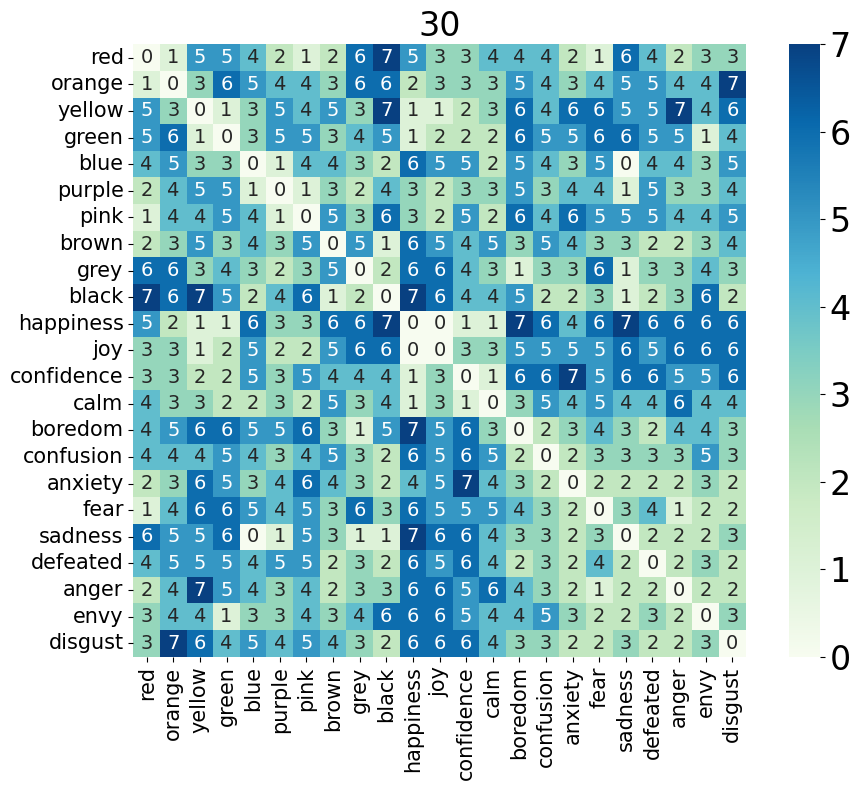

In [3]:
dissim_mtx = core.create_dissim_amy(raw, sub_no=30, unique_words=unique_words)
dist = core.cal_dissim2dist(dissim_mtx)

viz.plt_dissim_heatmap(
    dissim_mtx,
    mode_dissim=True,
    save=False,
    figpath="30",
    annotation=True)

In [4]:
a = np.array([[1,0,1],
              [0,1,1],
              [1,1,1]])
a

array([[1, 0, 1],
       [0, 1, 1],
       [1, 1, 1]])

In [5]:
b = np.linalg.pinv(a)
np.sum(b)

0.9999999999999996

In [6]:
a_1 = np.eye(3)
a_1

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [7]:
a_2 = np.ones((3,3))
a_2

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [8]:
b_1 = np.linalg.pinv(a_1)
np.sum(b_1)

3.0

In [9]:
b_2 = np.linalg.pinv(a_2)
np.sum(b_2)

0.9999999999999994

In [10]:
a_3 = np.array([[1,1,1,1],
                [1,1,1,0],
                [1,1,1,1],
                [1,0,1,1]])
a_3

array([[1, 1, 1, 1],
       [1, 1, 1, 0],
       [1, 1, 1, 1],
       [1, 0, 1, 1]])

In [11]:
b_3 = np.linalg.pinv(a_3)
np.sum(b_3)

0.9999999999999998

In [12]:
a_4 = np.array([[1,1,1,0],
                [1,1,1,1],
                [1,1,1,0],
                [0,1,0,1]])
a_4

array([[1, 1, 1, 0],
       [1, 1, 1, 1],
       [1, 1, 1, 0],
       [0, 1, 0, 1]])

In [13]:
b_4 = np.linalg.pinv(a_4)
np.sum(b_4)

1.0000000000000004

In [14]:
v = np.array([0,1,0,0])

v_col = v.reshape(-1,1)
x = np.array([[1]])

a_5 = np.block([
    [a_4,      v_col],
    [v.reshape(1,-1), x]
])

print(a_5)

[[1 1 1 0 0]
 [1 1 1 1 1]
 [1 1 1 0 0]
 [0 1 0 1 0]
 [0 1 0 0 1]]


In [15]:
b_5 = np.linalg.pinv(a_5)
np.sum(b_5)

0.9999999999999993

In [16]:
v = np.array([0,0,0,0,1])

v_col = v.reshape(-1,1)
x = np.array([[1]])

a_6 = np.block([
    [a_5,      v_col],
    [v.reshape(1,-1), x]
])

print(a_6)

[[1 1 1 0 0 0]
 [1 1 1 1 1 0]
 [1 1 1 0 0 0]
 [0 1 0 1 0 0]
 [0 1 0 0 1 1]
 [0 0 0 0 1 1]]


In [17]:
b_6 = np.linalg.pinv(a_6)
np.sum(b_6)

3.0000000000000004

In [18]:
# two-floor visualization
figpath = str(paths.figure("simulation"))

n_sub = 1
t_all = np.logspace(-5, 2, 100)

genmag_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

dissim_mtx = pd.DataFrame([[0, 1, 1000],
                           [1, 0, 1000],
                           [1000, 1000, 0]])

In [19]:
for sub in range(n_sub):
    print(f'subject: {sub}')
    dist = core.cal_dissim2dist(dissim_mtx)
    for i_t, t in enumerate(t_all):
        sim = core.cal_dist2sim(dist, t)
        genmag = core.cal_sim2genmag(sim)
        genmag_all.iloc[sub, i_t] = genmag

        spr = core.cal_dist2spread(dist, t)
        spr_all.iloc[sub, i_t] = spr

subject: 0


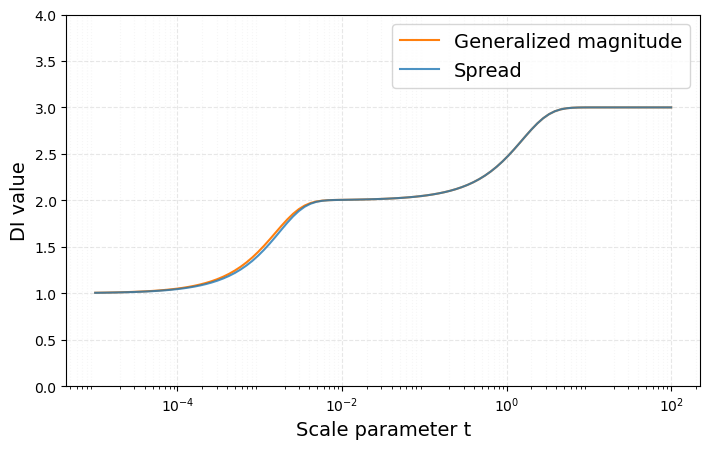

In [36]:
figsize = (7.2, 4.6)
ylim = [0, 4]

fig, ax = plt.subplots(figsize=figsize)

t_sorted = [pd.to_numeric(genmag_all.columns).to_numpy(),
            pd.to_numeric(spr_all.columns).to_numpy()]
y = [np.squeeze(genmag_all.to_numpy()), np.squeeze(spr_all.to_numpy())]
ax.plot(t_sorted[0], y[0], label="Generalized magnitude", color="tab:orange")
ax.plot(t_sorted[1], y[1], label="Spread", color="tab:blue", alpha=0.8)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.1)

ax.set_ylim(ylim)

ax.set_xlabel("Scale parameter t", fontsize=14)
ax.set_ylabel("DI value", fontsize=14)
ax.legend(fontsize=14)

fig.tight_layout()

out_png = os.path.join(figpath, "two_floors.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")

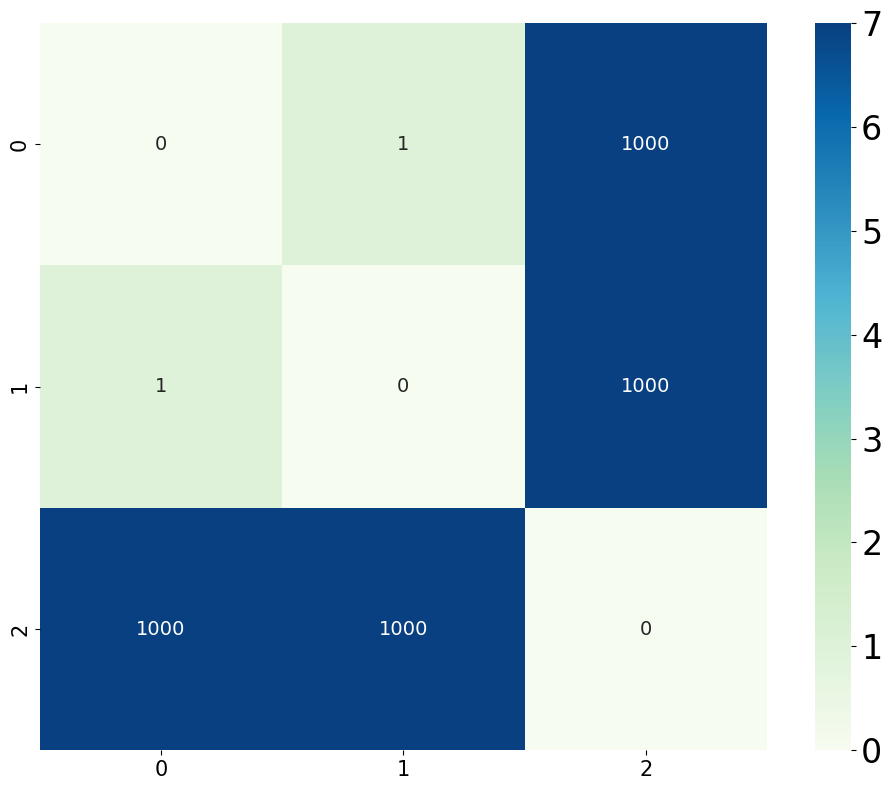

In [21]:
viz.plt_dissim_heatmap(
    dissim_mtx,
    mode_dissim=True,
    save=False,
    figpath="",
    annotation=True)

In [30]:
d_path = paths.source("Angus", "pref_dists.csv")
r = pd.read_csv(d_path)
r

,col1,col2,pID,dist
0,1,1,1,0.50
1,2,1,1,0.50
2,3,1,1,0.25
3,4,1,1,1.00
4,5,1,1,3.00
...,...,...,...,...
2731,8,12,19,3.00
2732,9,12,19,3.00
2733,10,12,19,3.50
2734,11,12,19,3.50


In [31]:
pre_dist = core.create_dissim_angus(r, -1)

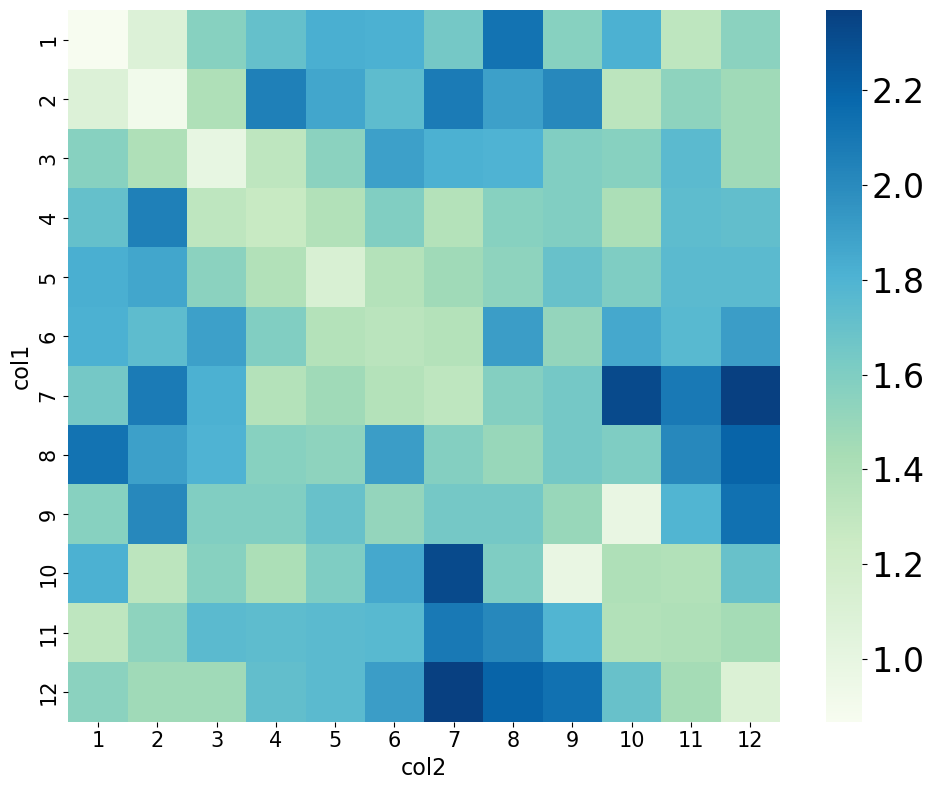

In [33]:
viz.plt_dissim_heatmap(
    pre_dist,
    mode_dissim=False,
    save=False,
    figpath="",
    annotation=False)

In [37]:
# Angus visualization
figpath = str(paths.figure("Angus"))

n_sub = 1
t_all = np.logspace(-5, 2, 100)

genmag_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

dissim_mtx = pre_dist

In [38]:
for sub in range(n_sub):
    print(f'subject: {sub}')
    dist = core.cal_dissim2dist(dissim_mtx)
    for i_t, t in enumerate(t_all):
        sim = core.cal_dist2sim(dist, t)
        genmag = core.cal_sim2genmag(sim)
        genmag_all.iloc[sub, i_t] = genmag

        spr = core.cal_dist2spread(dist, t)
        spr_all.iloc[sub, i_t] = spr

subject: 0


/home/jovyan/work/funcs/core.py:320: UserWarning: diag vals are not 0 in dissim
  warnings.warn(f"diag vals are not {diag_val} in {name}")
/home/jovyan/work/funcs/core.py:320: UserWarning: diag vals are not 0 in dist
  warnings.warn(f"diag vals are not {diag_val} in {name}")
/home/jovyan/work/funcs/core.py:320: UserWarning: diag vals are not 1 in A
  warnings.warn(f"diag vals are not {diag_val} in {name}")
/home/jovyan/work/funcs/core.py:320: UserWarning: diag vals are not 0 in D
  warnings.warn(f"diag vals are not {diag_val} in {name}")


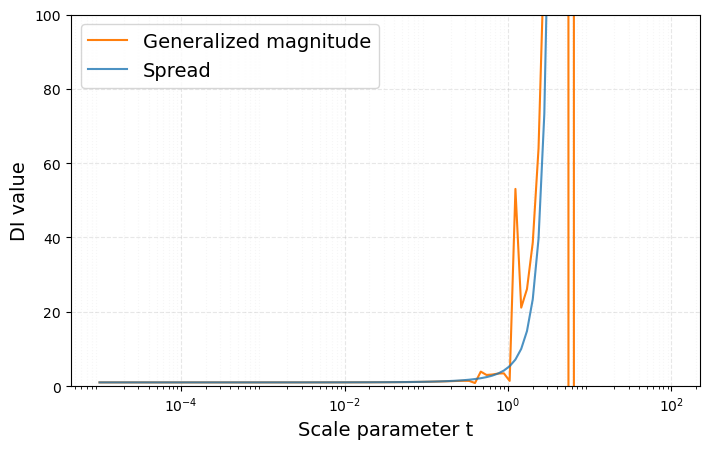

In [43]:
figsize = (7.2, 4.6)
ylim = [0, 100]

fig, ax = plt.subplots(figsize=figsize)

t_sorted = [pd.to_numeric(genmag_all.columns).to_numpy(),
            pd.to_numeric(spr_all.columns).to_numpy()]
y = [np.squeeze(genmag_all.to_numpy()), np.squeeze(spr_all.to_numpy())]
ax.plot(t_sorted[0], y[0], label="Generalized magnitude", color="tab:orange")
ax.plot(t_sorted[1], y[1], label="Spread", color="tab:blue", alpha=0.8)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.1)

ax.set_ylim(ylim)

ax.set_xlabel("Scale parameter t", fontsize=14)
ax.set_ylabel("DI value", fontsize=14)
ax.legend(fontsize=14)

fig.tight_layout()

out_png = os.path.join(figpath, "Angus_preference.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")